# Metrics by OFEV coverage start

This notebook reads `outputs/OFEV_determinist/metrics_all_models_summary.csv` and creates one figure per OFEV `coverage_start`.

Each figure has three subplots, one for each metric: `NSE`, `KGE`, and `RMSE`.
The grouping key is the `coverage_start` of the first `OFEV` row for each `ofev_model`.

Legend rule: rows where `model == 'OFEV'` are labeled as `<ofev_model> - OFEV`.

In [16]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120

In [17]:
try:
    BASE_DIR = Path(__file__).resolve().parents[1]
except NameError:
    BASE_DIR = Path.cwd().resolve()
    if BASE_DIR.name == 'notebooks':
        BASE_DIR = BASE_DIR.parent

DATA_PATH = BASE_DIR / 'outputs' / 'OFEV_determinist' / 'metrics_all_models_summary.csv'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'OFEV_determinist' / 'coverage_start_subplots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ['NSE', 'KGE', 'RMSE']

df = pd.read_csv(DATA_PATH)
df['coverage_start'] = pd.to_datetime(df['coverage_start'])
df['coverage_end'] = pd.to_datetime(df['coverage_end'])

reference = (
    df.loc[df['model'].eq('OFEV'), ['ofev_model', 'coverage_start']]
      .drop_duplicates(subset=['ofev_model'], keep='first')
      .rename(columns={'coverage_start': 'coverage_start_anchor'})
)

df = df.merge(reference, on=['ofev_model'], how='left')
df['coverage_start_anchor'] = pd.to_datetime(df['coverage_start_anchor'], errors='coerce')
df['series_label'] = df['ofev_model'] + ' - ' + df['model'].where(df['model'].ne('OFEV'), 'OFEV')

df[['ofev_model', 'lead_time', 'model', 'coverage_start', 'coverage_start_anchor']].head()

,ofev_model,lead_time,model,coverage_start,coverage_start_anchor
0,C1E_Ctrl,6,OFEV,2020-09-15 13:00:00,2020-09-15 13:00:00
1,C1E_Ctrl,6,Hydrique_ML,2020-09-16 00:00:00,2020-09-15 13:00:00
2,C1E_Ctrl,6,Hydrique_Curve,2020-09-16 00:00:00,2020-09-15 13:00:00
3,C1E_Ctrl,6,SIG_CNR,2020-09-15 14:00:00,2020-09-15 13:00:00
4,C1E_Ctrl,12,OFEV,2020-09-15 19:00:00,2020-09-15 13:00:00


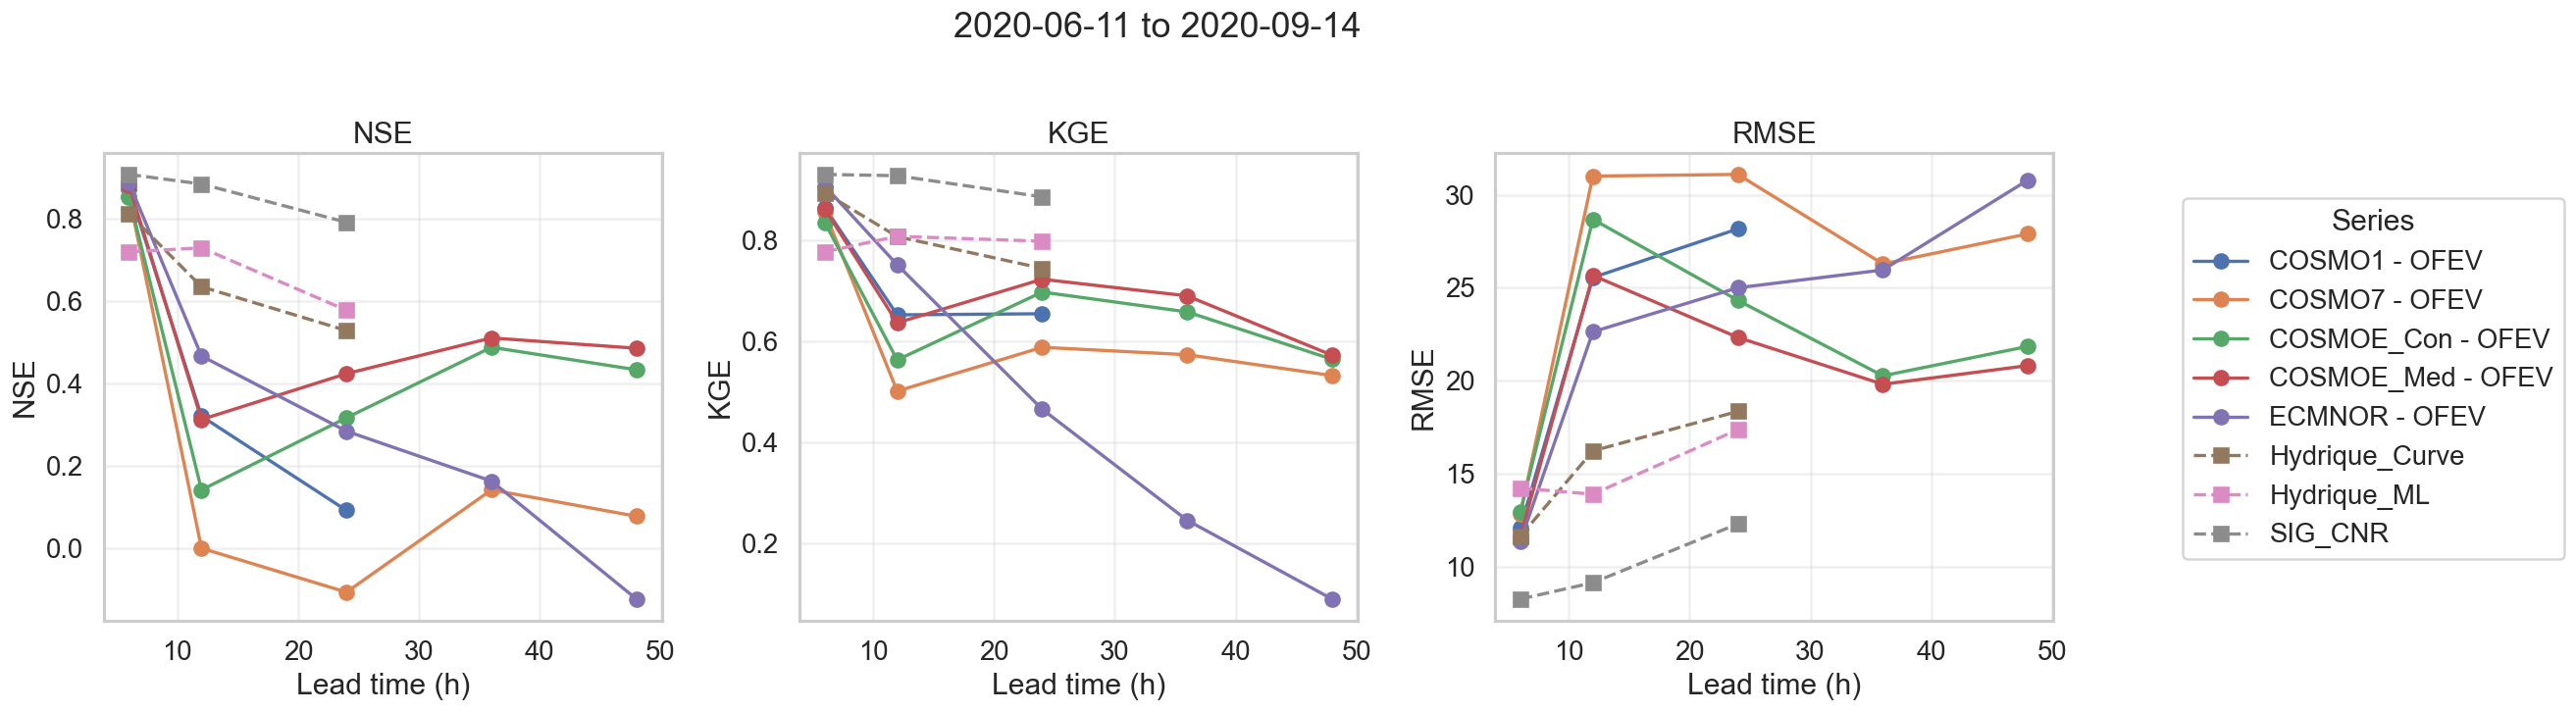

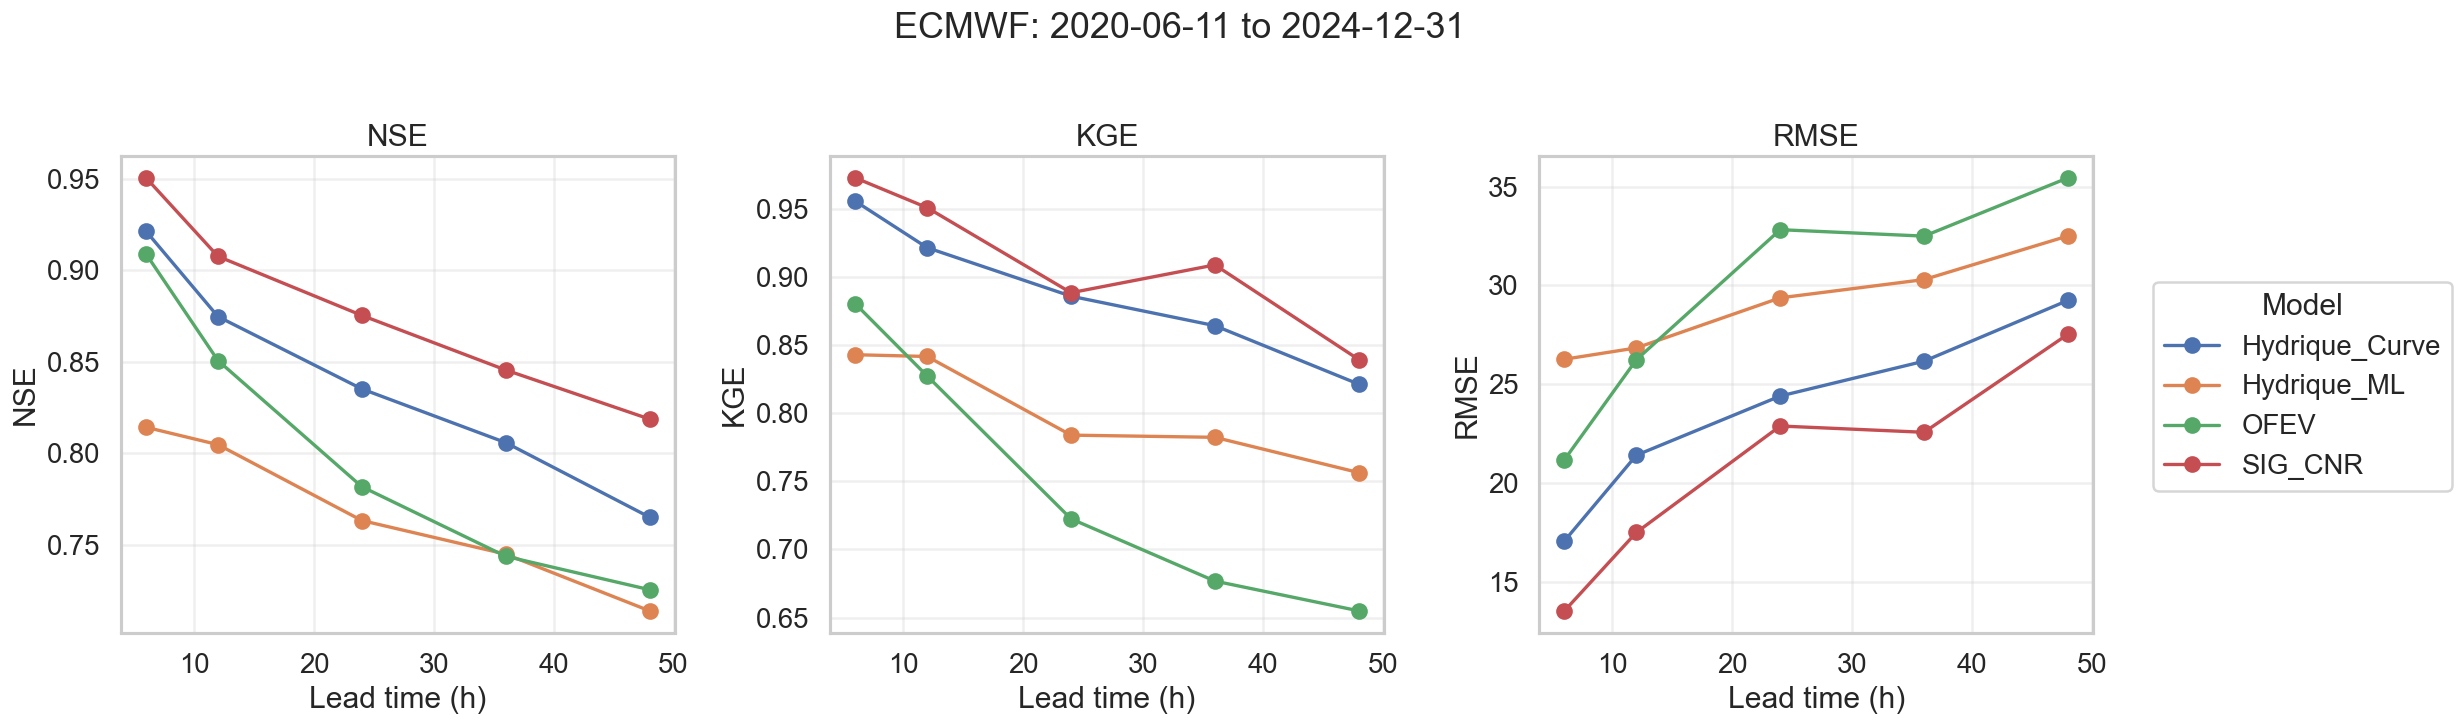

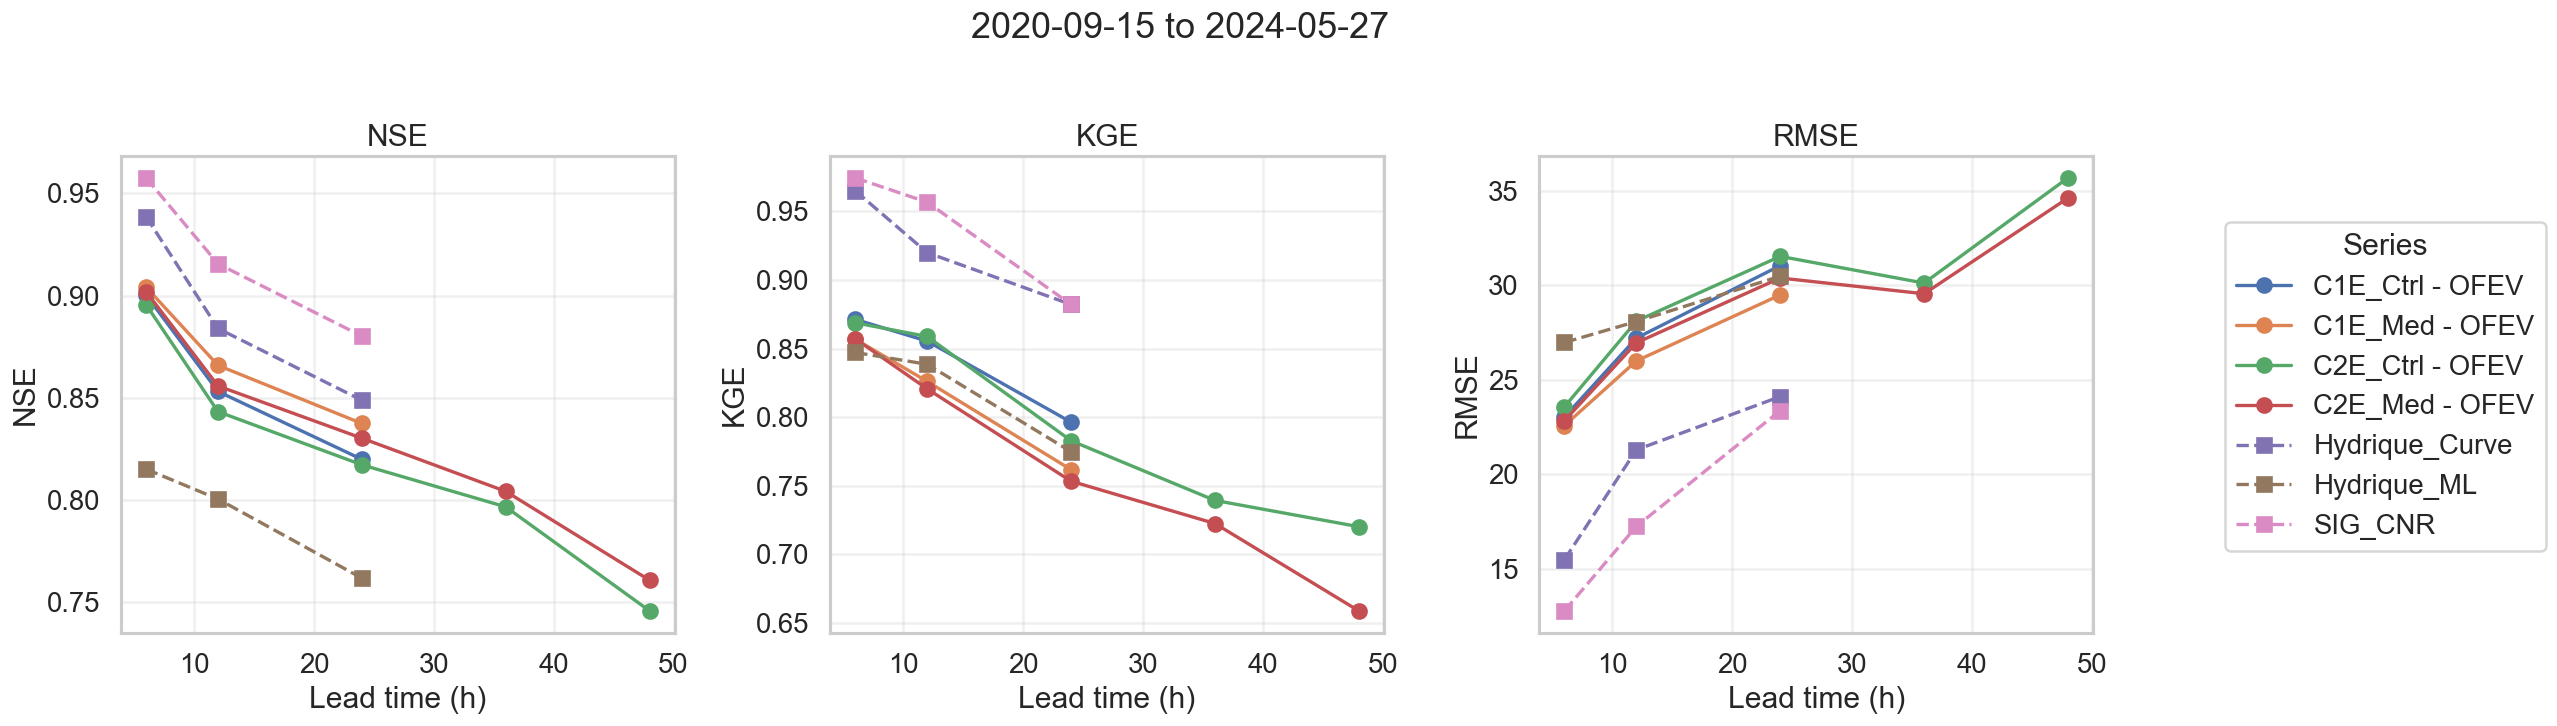

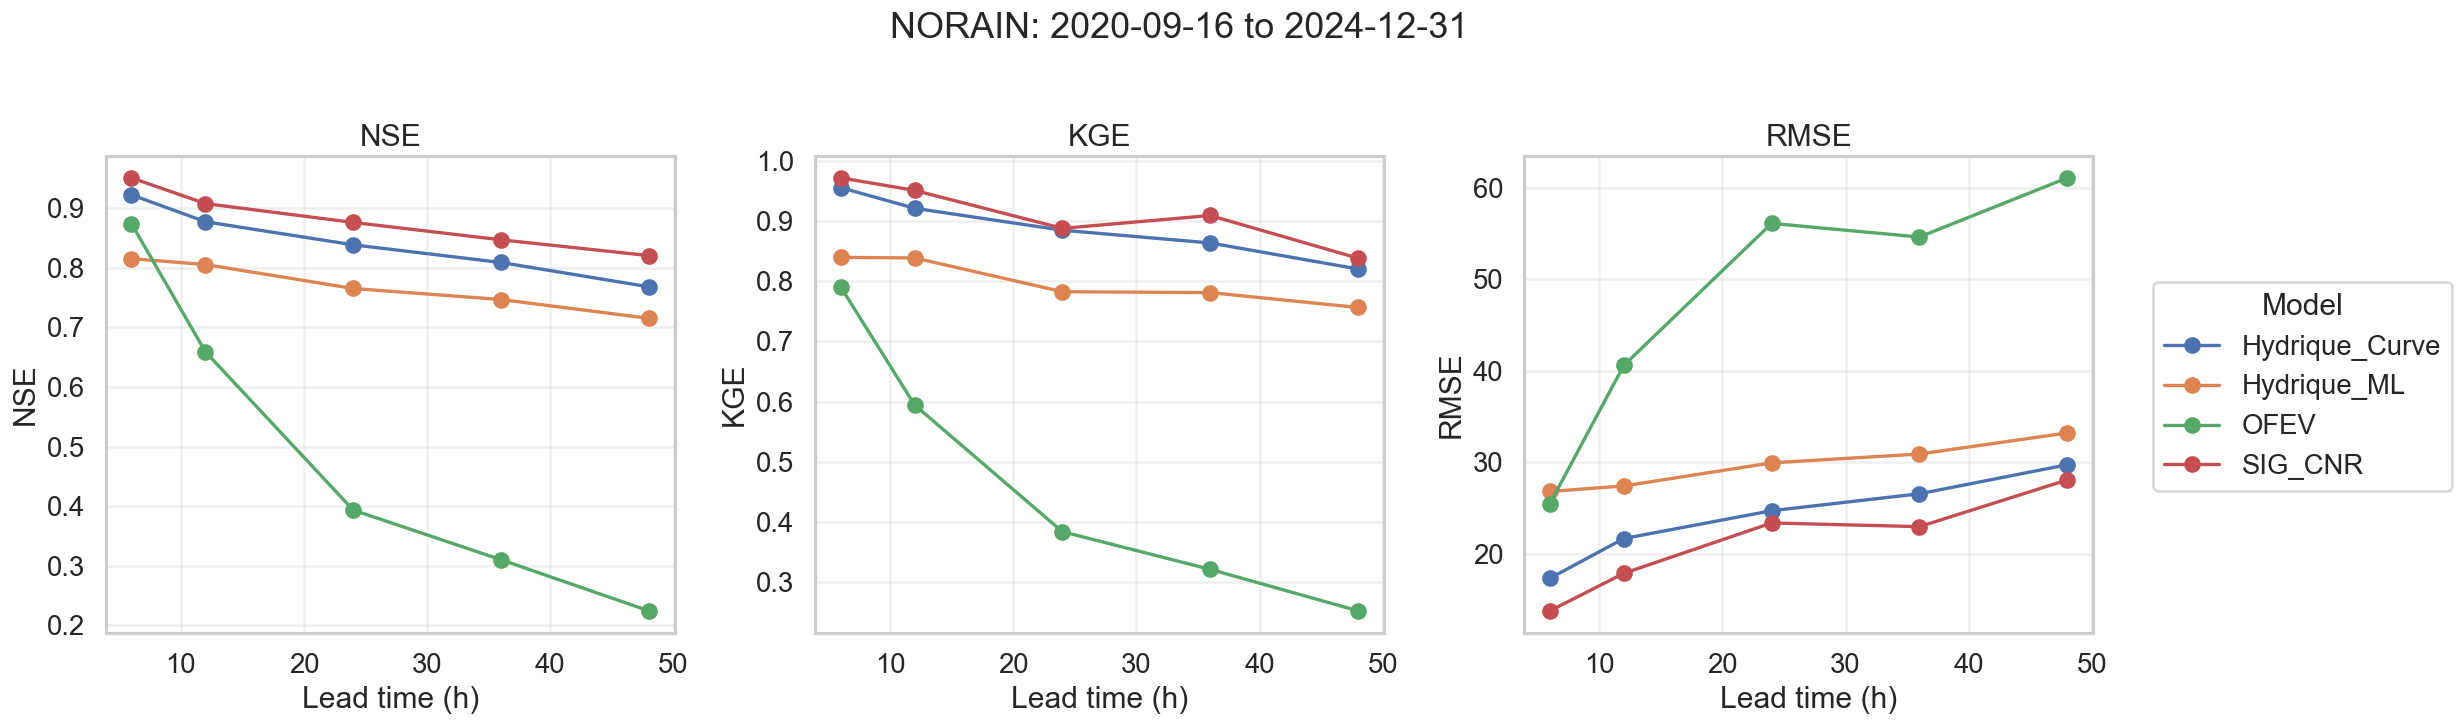

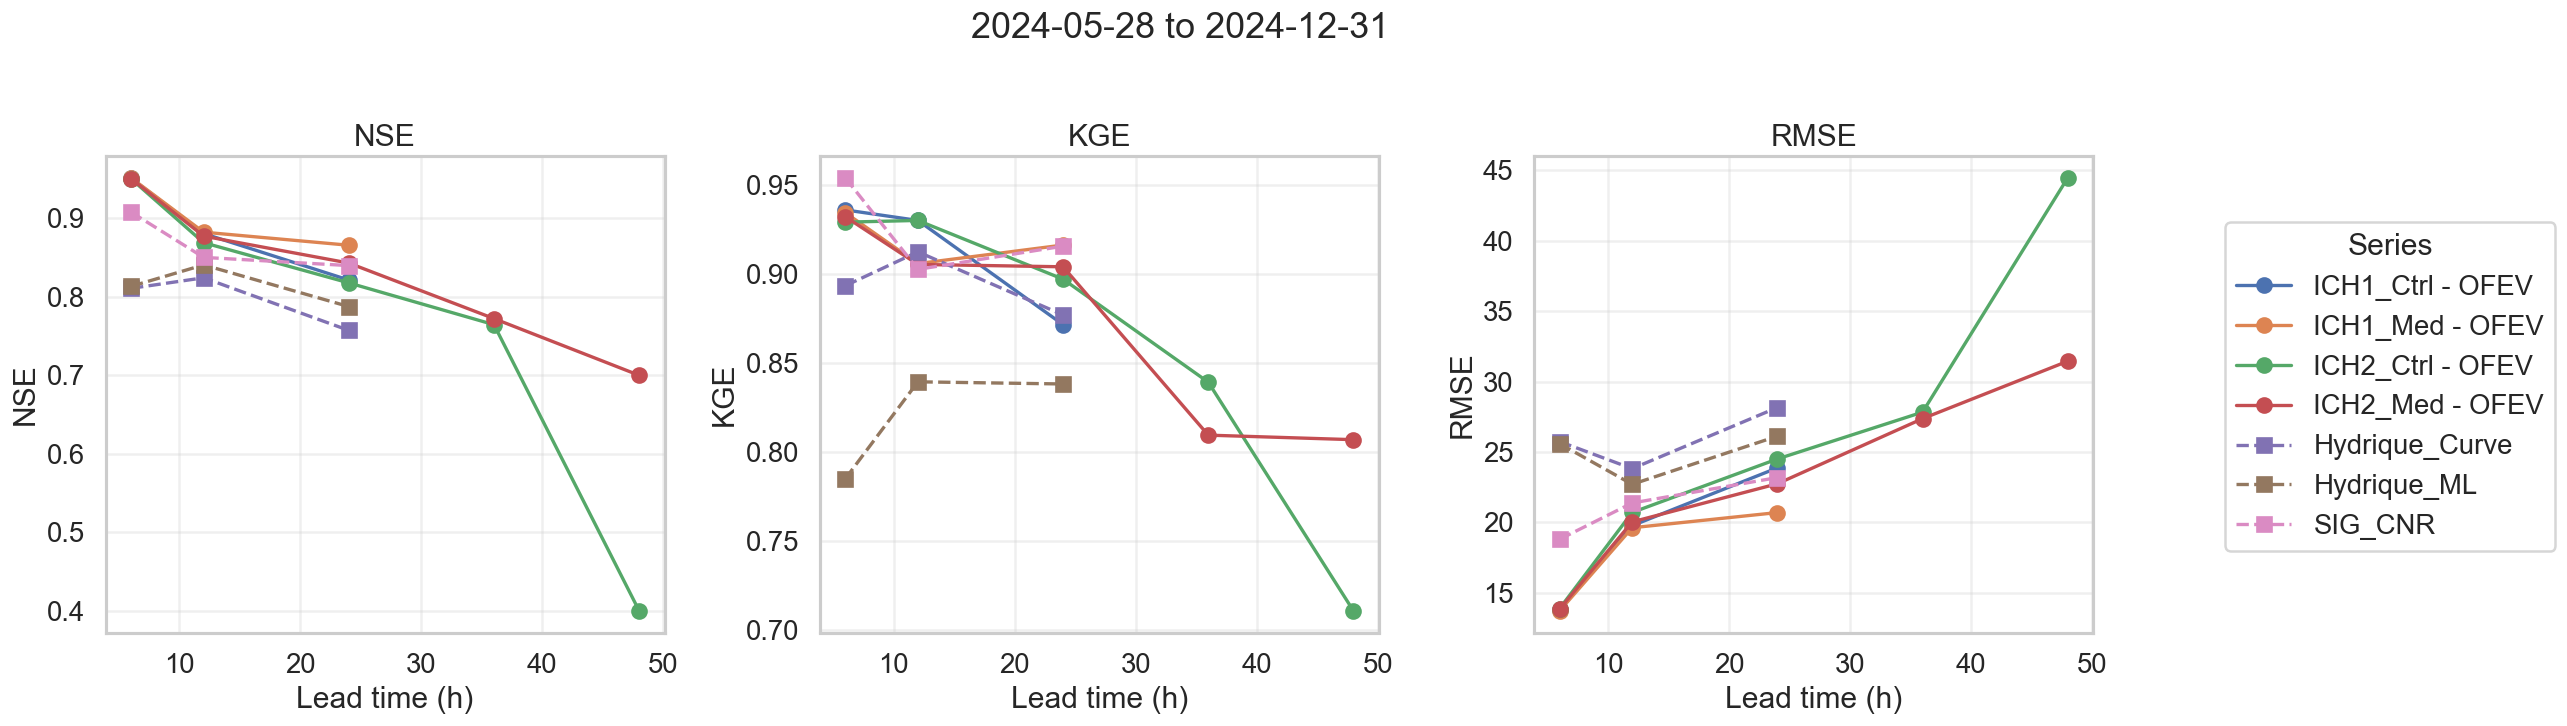

5

In [28]:
def plot_group(group: pd.DataFrame):
    group = group.sort_values(['ofev_model', 'model', 'lead_time']).copy()

    # Main figure: exclude NORAIN and ECMWF ofev_models
    main_group = group[~group['ofev_model'].isin(['NORAIN', 'ECMWF'])].copy()

    fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 6), sharex=True)
    if len(METRICS) == 1:
        axes = [axes]

    # Plot OFEV series separately (one per ofev_model)
    ofev_rows = main_group[main_group['model'] == 'OFEV']
    ofev_models = ofev_rows['ofev_model'].unique()

    # For non-OFEV models, keep only first-ofev_model series as representative and remove ofev_model from legend
    non_ofev_models = [m for m in main_group['model'].unique() if m != 'OFEV']
    rep_series = {}
    for m in non_ofev_models:
        sub = main_group[main_group['model'] == m].sort_values(['ofev_model', 'lead_time'])
        if sub.empty:
            continue
        first_ofev = sub['ofev_model'].iloc[0]
        rep = sub[sub['ofev_model'] == first_ofev].sort_values('lead_time')
        rep_series[m] = rep

    for ax, metric in zip(axes, METRICS):
        # plot OFEV lines (one per ofev_model)
        for om in ofev_models:
            sub = ofev_rows[ofev_rows['ofev_model'] == om].sort_values('lead_time')
            if sub.empty:
                continue
            ax.plot(sub['lead_time'], sub[metric], marker='o', linewidth=2, label=f'{om} - OFEV')

        # plot representative non-OFEV series (label only by model)
        for m, rep in rep_series.items():
            ax.plot(rep['lead_time'], rep[metric], marker='s', linestyle='--', linewidth=2, label=m)

        ax.set_title(metric)
        ax.set_xlabel('Lead time (h)')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    
    # Get coverage_start and coverage_end of the first OFEV model
    first_ofev_model_name = ofev_models[0] if len(ofev_models) > 0 else None
    if first_ofev_model_name is not None:
        first_ofev_data = ofev_rows[ofev_rows['ofev_model'] == first_ofev_model_name].iloc[0]
        coverage_start = first_ofev_data['coverage_start'].date()
        coverage_end = first_ofev_data['coverage_end'].date()
        title_str = f'{coverage_start} to {coverage_end}'
    else:
        title_str = f'Metrics'
    
    fig.legend(handles, labels, title='Series', bbox_to_anchor=(0.93, 0.5), loc='center left')
    fig.suptitle(title_str, y=1.02)
    fig.tight_layout(rect=(0, 0, 0.90, 1))
    return fig


# Secondary figures for NORAIN and ECMWF ofev_models (one figure per model per anchor)
def plot_special(group: pd.DataFrame):
    special = group[group['ofev_model'].isin(['NORAIN', 'ECMWF'])].copy()
    if special.empty:
        return []

    figs = []
    # create one figure per special ofev_model
    for om in ['NORAIN', 'ECMWF']:
        sub_all = special[special['ofev_model'] == om].sort_values(['model', 'lead_time'])
        if sub_all.empty:
            continue

        fig, axes = plt.subplots(1, len(METRICS), figsize=(20, 6), sharex=True)
        if len(METRICS) == 1:
            axes = [axes]

        # Plot all models for this ofev_model
        models_in_ofev = sub_all['model'].unique()
        for ax, metric in zip(axes, METRICS):
            for m in models_in_ofev:
                sub = sub_all[sub_all['model'] == m].sort_values('lead_time')
                if sub.empty:
                    continue
                ax.plot(sub['lead_time'], sub[metric], marker='o', linewidth=2, label=m)

            ax.set_title(metric)
            ax.set_xlabel('Lead time (h)')
            ax.set_ylabel(metric)
            ax.grid(True, alpha=0.3)

        handles, labels = axes[0].get_legend_handles_labels()
        
        # Get coverage_start and coverage_end for this ofev_model
        om_data = sub_all.iloc[0]
        coverage_start = om_data['coverage_start'].date()
        coverage_end = om_data['coverage_end'].date()
        title_str = f'{om}: {coverage_start} to {coverage_end}'
        
        fig.legend(handles, labels, title='Model', bbox_to_anchor=(0.90, 0.5), loc='center left')
        fig.suptitle(title_str, y=1.02)
        fig.tight_layout(rect=(0, 0, 0.90, 1))

        figs.append((om, fig))

    return figs


plots = []
plot_df = df.dropna(subset=['coverage_start_anchor']).copy()

for anchor, group in plot_df.groupby('coverage_start_anchor', sort=True):
    fig_main = plot_group(group)
    plots.append((anchor, 'main', fig_main))

    file_name = f'metrics_by_coverage_start_{anchor:%Y%m%d_%H%M}.png'
    fig_main.savefig(OUTPUT_DIR / file_name, dpi=200, bbox_inches='tight')
    display(fig_main)
    plt.close(fig_main)

    fig_specials = plot_special(group)
    for ofev_model_name, fig_special in fig_specials:
        plots.append((anchor, f'special_{ofev_model_name}', fig_special))
        file_name2 = f'metrics_{ofev_model_name}_{anchor:%Y%m%d_%H%M}.png'
        fig_special.savefig(OUTPUT_DIR / file_name2, dpi=200, bbox_inches='tight')
        display(fig_special)
        plt.close(fig_special)

len(plots)

## Notes

- If you want a different grouping key, change the `coverage_start_anchor` merge in the preparation cell.
- If you want one figure per `ofev_model` instead of one figure per OFEV anchor, that can be changed with a small adjustment.